#### hair analysis 

In [2]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import time

In [3]:

def detect_hair_mask(image, ksize = 4):
    """
    Detect hair (black, white, or mixed) in dermoscopy image.
    
    Args:
        image: RGB image (numpy array)
    Returns:
        hair_mask: Binary mask where hair pixels = 255
    """
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    # Define kernel for morphological operations
    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (ksize, ksize))
    
    # Detect dark (black) hair
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, black_hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    
    # Detect light (white) hair
    tophat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel)
    _, white_hair_mask = cv2.threshold(tophat, 10, 255, cv2.THRESH_BINARY)
    
    # Combine both masks (handles mixed hair automatically)
    combined_hair_mask = cv2.bitwise_or(black_hair_mask, white_hair_mask)
    
    return combined_hair_mask


def create_blue_pen_mask(img):

    # 2. Convert to HSV
    hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Typical wide blue range
    lower_blue = np.array([100, 50, 50])
    upper_blue = np.array([140, 255, 255])

    # Create mask from both ranges and combine
    mask = cv2.inRange(hsv_img, lower_blue, upper_blue)
    
    return mask
    

def remove_hair(img_id, hair_mask=None, visual=False, pen_mark = False, radius = 3):
    """
    Remove hair using inpainting.
    
    Args:
        image: RGB image
        hair_mask: Optional pre-computed hair mask. If None, will detect automatically.
    Returns:
        inpainted_image: RGB image with hair removed
    """
    img_path = '../data/imgs/' + img_id
    img = cv2.imread(img_path)

    if hair_mask is None:
        hair_mask = detect_hair_mask(img)
    
    # Inpaint using the combined hair mask
    inpainted = cv2.inpaint(img, hair_mask, inpaintRadius=radius, 
                            flags=cv2.INPAINT_TELEA)
    
    if pen_mark:
        pen_mask = create_blue_pen_mask(inpainted)
        inpainted = cv2.inpaint(inpainted, pen_mask, inpaintRadius = 3, flags = cv2.INPAINT_TELEA)
    
    if visual:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        inpainted_rgb = cv2.cvtColor(inpainted, cv2.COLOR_BGR2RGB)
        
        fig, ax = plt.subplots(1,3, figsize = (10, 8))
        ax[0].imshow(img_rgb)
        ax[0].set_title('original')

        ax[1].imshow(hair_mask, cmap='grey')
        ax[1].set_title('hair_mask')

        ax[2].imshow(inpainted_rgb)
        ax[2].set_title('cleaned')

        plt.tight_layout()
        plt.show()
        
    return 

In [4]:
def calculate_hair_coverage(img_id):
    """
    Calculate probability of lesion covered by hair.
    
    Args:
        image: RGB image
    Returns:
        coverage_probability: float (0-1)

    """
    if not isinstance(img_id, str):
        return np.nan
    
    img_path = '../data/imgs/' + img_id
    mask_path = '../data/masks/' + img_id.replace('.png', '_mask.png')

    image = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Get hair mask within lesion
    hair_mask = detect_hair_mask(image)

    if hair_mask.shape != mask.shape:
        return np.nan
    
    # Count pixels (area)

    lesion_area = np.sum(mask > 0) #accounting for lesion area
    hair_on_lesion = np.logical_and(hair_mask > 0, mask > 0)
    coverage = np.sum(hair_on_lesion) / lesion_area if lesion_area > 0 else 0 
    
    return round(coverage, 4)

In [ ]:
start = time.time()
df_ann = pd.read_csv('../data/annotations_combined.csv')
df_ann['hair_cvg'] = df_ann['img_id'].apply(calculate_hair_coverage)
print('Running time (min): ', round((time.time()-start) / 60, 2))

(1089, 1089)

In [ ]:
# check error

img_id = 'PAT_2051_4356_460.png'

img_path = '../data/imgs/' + img_id
mask_path = '../data/masks/' + img_id.replace('.png', '_mask.png')

image = cv2.imread(img_path)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE).astype('float')
new_mask = mask > 0.5  # bool values
mask.dtype

dtype('uint8')

In [ ]:
img_id = 'PAT_2051_4356_460.png'

img_path = '../data/imgs/' + img_id
mask_path = '../data/masks/' + img_id.replace('.png', '_mask.png')

img = cv2.imread(img_path)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

np.unique(mask)


array([  0,  64, 128, 191, 255], dtype=uint8)

In [25]:
df_ann

,img_id,hair_1,pen_1,hair_2,pen_2,hair_3,pen_3,hair_4,pen_4,hair_5,pen_5,hair_rating,pen_rating
0,PAT_1431_1495_511.png,2.0,0.0,1.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0
1,PAT_2051_4356_460.png,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0
2,PAT_1255_876_939.png,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,PAT_963_1820_823.png,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,PAT_419_832_706.png,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1632,PAT_1989_4061_934.png,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1633,PAT_2036_4281_271.png,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0
1634,PAT_2046_4323_762.png,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0
1635,PAT_2085_4506_726.png,2.0,0.0,2.0,0.0,2.0,0.0,2.0,0.0,2.0,0.0,2.0,0.0


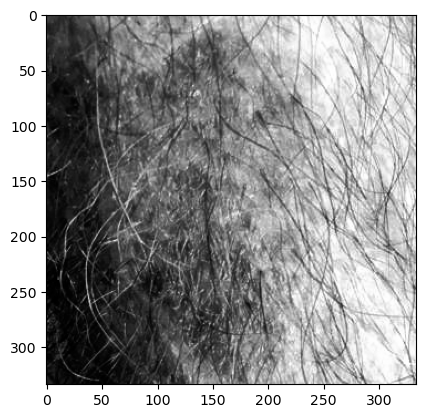

In [5]:
img_path = img_path = '../data/imgs/' + 'PAT_1181_659_231.png'
img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img_eq = cv2.equalizeHist(img_gray)
plt.imshow(img_eq, cmap = 'grey');

In [6]:
def show_rgb_channel(img_id):
    img_path = '../data/imgs/' + img_id
    img_rgb = plt.imread(img_path)
    channel = ['red', 'green', 'blue']

    fig, ax = plt.subplots(1,3, figsize = (10,8))

    for i in range(3):
        ax[i].imshow(img_rgb[:,:,i], cmap = 'grey')
        ax[i].set_title(f'{channel[i]} channel')
        ax[i].axis('off')
    
    plt.tight_layout()
    plt.show()

    return

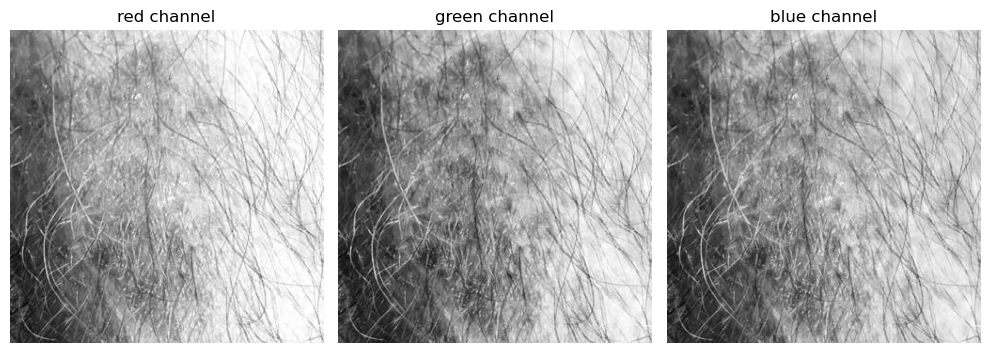

In [7]:
show_rgb_channel('PAT_1181_659_231.png')

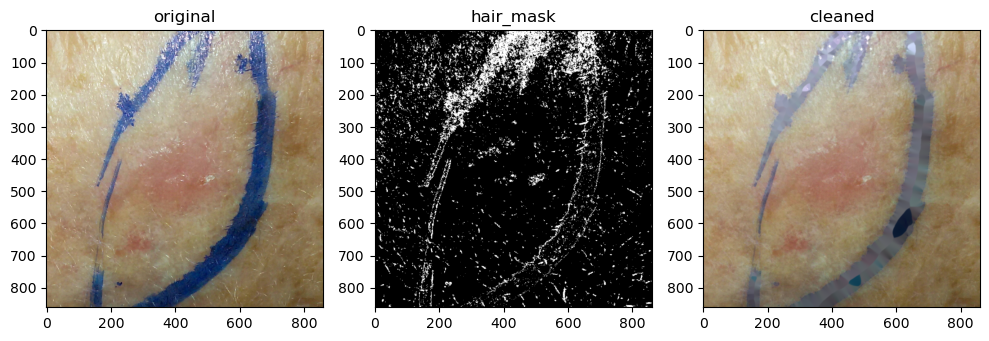

In [8]:
img_id = 'PAT_597_1139_181.png'
remove_hair(img_id, visual = True, pen_mark = True)

In [21]:
# preprocessing annotations

df_ann = pd.read_csv('../data/annotations_combined.csv')

# keep only relevant cols
df_ann.drop(columns = 'group_id', inplace = True) 

print('Before')
print(f'cols: {df_ann.shape[1]}, rows: {df_ann.shape[0]}')

# drop rows with all NA values
df_ann.dropna(how='all', inplace = True)

print(df_ann.head())

print()

# change all NA values to 0
df_ann.fillna(value = 0, inplace = True)

print('After')
print(f'cols: {df_ann.shape[1]}, rows: {df_ann.shape[0]}')
print(df_ann.head())


Before
cols: 11, rows: 1637
                  img_id  hair_1  pen_1  hair_2  pen_2  hair_3  pen_3  hair_4  \
0  PAT_1431_1495_511.png     2.0    0.0     1.0    0.0     2.0    0.0     1.0   
1  PAT_2051_4356_460.png     2.0    1.0     1.0    1.0     1.0    1.0     1.0   
2   PAT_1255_876_939.png     0.0    0.0     0.0    0.0     0.0    0.0     0.0   
3   PAT_963_1820_823.png     1.0    0.0     1.0    0.0     1.0    0.0     0.0   
4    PAT_419_832_706.png     0.0    1.0     0.0    1.0     0.0    1.0     0.0   

   pen_4  hair_5  pen_5  
0    0.0     NaN    NaN  
1    0.0     NaN    NaN  
2    1.0     NaN    NaN  
3    1.0     NaN    NaN  
4    1.0     NaN    NaN  

After
cols: 11, rows: 1636
                  img_id  hair_1  pen_1  hair_2  pen_2  hair_3  pen_3  hair_4  \
0  PAT_1431_1495_511.png     2.0    0.0     1.0    0.0     2.0    0.0     1.0   
1  PAT_2051_4356_460.png     2.0    1.0     1.0    1.0     1.0    1.0     1.0   
2   PAT_1255_876_939.png     0.0    0.0     0.0    0.0    

In [22]:
# modify annotations (voting)

df_ann['hair_rating'] = df_ann[['hair_1', 'hair_2', 'hair_3', 'hair_4', 'hair_5']].apply(
    lambda row: row.mode().max(), axis=1
)

df_ann['pen_rating'] = df_ann[['pen_1', 'pen_2', 'pen_3', 'pen_4', 'pen_5']].apply(
    lambda row: row.mode().max(), axis=1
)

In [33]:
df_ann['img_id'].isna().sum()

np.int64(0)

In [35]:
# add hair coverage (based on lesion)

start = time.time()

df_ann['hair_cvg'] = df_ann['img_id'].apply(calculate_hair_coverage) # apply function

print('Running time (min): ', round((time.time()-start) / 60, 2))
df_ann.to_csv('../data/annotations.csv')
print('Saved...')

[ WARN:0@2902.595] global loadsave.cpp:278 findDecoder imread_('../data/imgs/PAT_32_44_211'): can't open/read file: check file path/integrity
[ WARN:0@2902.595] global loadsave.cpp:278 findDecoder imread_('../data/masks/PAT_32_44_211'): can't open/read file: check file path/integrity


error: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


In [17]:
df_ann['img_id'].isna().sum()

np.int64(0)

In [18]:
df_ann.sort_values('hair_rating', ascending = False).head(10)

,img_id,hair_1,pen_1,hair_2,pen_2,hair_3,pen_3,hair_4,pen_4,hair_5,pen_5,hair_rating,pen_rating
665,PAT_561_1069_418.png,1.0,0.0,2.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0
1088,PAT_1798_3455_379.png,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0
1411,PAT_587_3431_6.png,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0
1029,PAT_1549_1882_230.png,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0
1030,PAT_1552_1895_190.png,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0
1035,PAT_1671_3008_622.png,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0
1048,PAT_2021_4180_381.png,3.0,1.0,3.0,1.0,3.0,1.0,3.0,1.0,3.0,1.0,3.0,1.0
1052,PAT_2109_4598_112.png,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0
1067,PAT_1216_760_593.png,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0
161,PAT_201_946_262.png,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0,3.0,0.0


In [ ]:
# change hair / pen removal function based on annotations
